# 03 Exploratory Analysis

Purpose: explore relationships between income, GDP, housing pressure, population growth, and innovation across 20 cities × 5 years.

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False


def find_project_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'data' / 'raw' / 'city_panel.csv').exists():
            return base
    raise FileNotFoundError(
        f'Cannot find data/raw/city_panel.csv (cwd={Path.cwd()})'
    )


ROOT = find_project_root()
PANEL_PATH = ROOT / 'data' / 'raw' / 'city_panel.csv'
SCORES_PATH = ROOT / 'data' / 'processed' / 'yeoi_scores.csv'

# Load processed data (cleaned panel + scores)
panel = pd.read_csv(PANEL_PATH)
scores = pd.read_csv(SCORES_PATH)
print(f'Panel: {panel.shape}  ← {PANEL_PATH}')
print(f'Scores: {scores.shape}')

hb = panel['housing_burden'].dropna()
hp = panel['house_price'].dropna()
print(
    f'Housing burden (×100): {hb.min()*100:.1f}% – {hb.max()*100:.1f}%, '
    f'median {hb.median()*100:.1f}%'
)
if (hp < 1000).any():
    bad = panel.loc[panel['house_price'] < 1000, 'city'].unique()
    raise ValueError(
        f'house_price still looks like NBS index (~100) for {list(bad)}. '
        'Run: uv run python -m uei.download_data, then re-run this cell.'
    )

Panel: (100, 20)  ← /Users/zhanglelong/work/git/youth-economic-opportunity-index-1/data/raw/city_panel.csv
Scores: (100, 13)
Housing burden (×100): 15.3% – 85.5%, median 33.6%


## 1. Distribution Overview

How are the core metrics distributed across the 100 city-year observations?

**How to read the x-axes**
- **GDP / Income:** yuan per person per year
- **Entry salary:** yuan per month (fresh graduate average)
- **Population growth:** year-on-year change in **percent** (not decimal)
- **R&D / Innovation:** 100M yuan
- **Housing pressure:** `house_price / disposable_income` as **percent**; all cities use new-home price in **yuan/sqm** (China Index Academy / gotohui annual mean)
- **Rent burden:** `rent_monthly × 12 / disposable_income` as **percent**
- **Job postings:** count
- **Listed companies:** count
- **University quality:** count (MOE-listed universities)

Housing Pressure plot data: 15.3% – 85.5%, median 33.6%


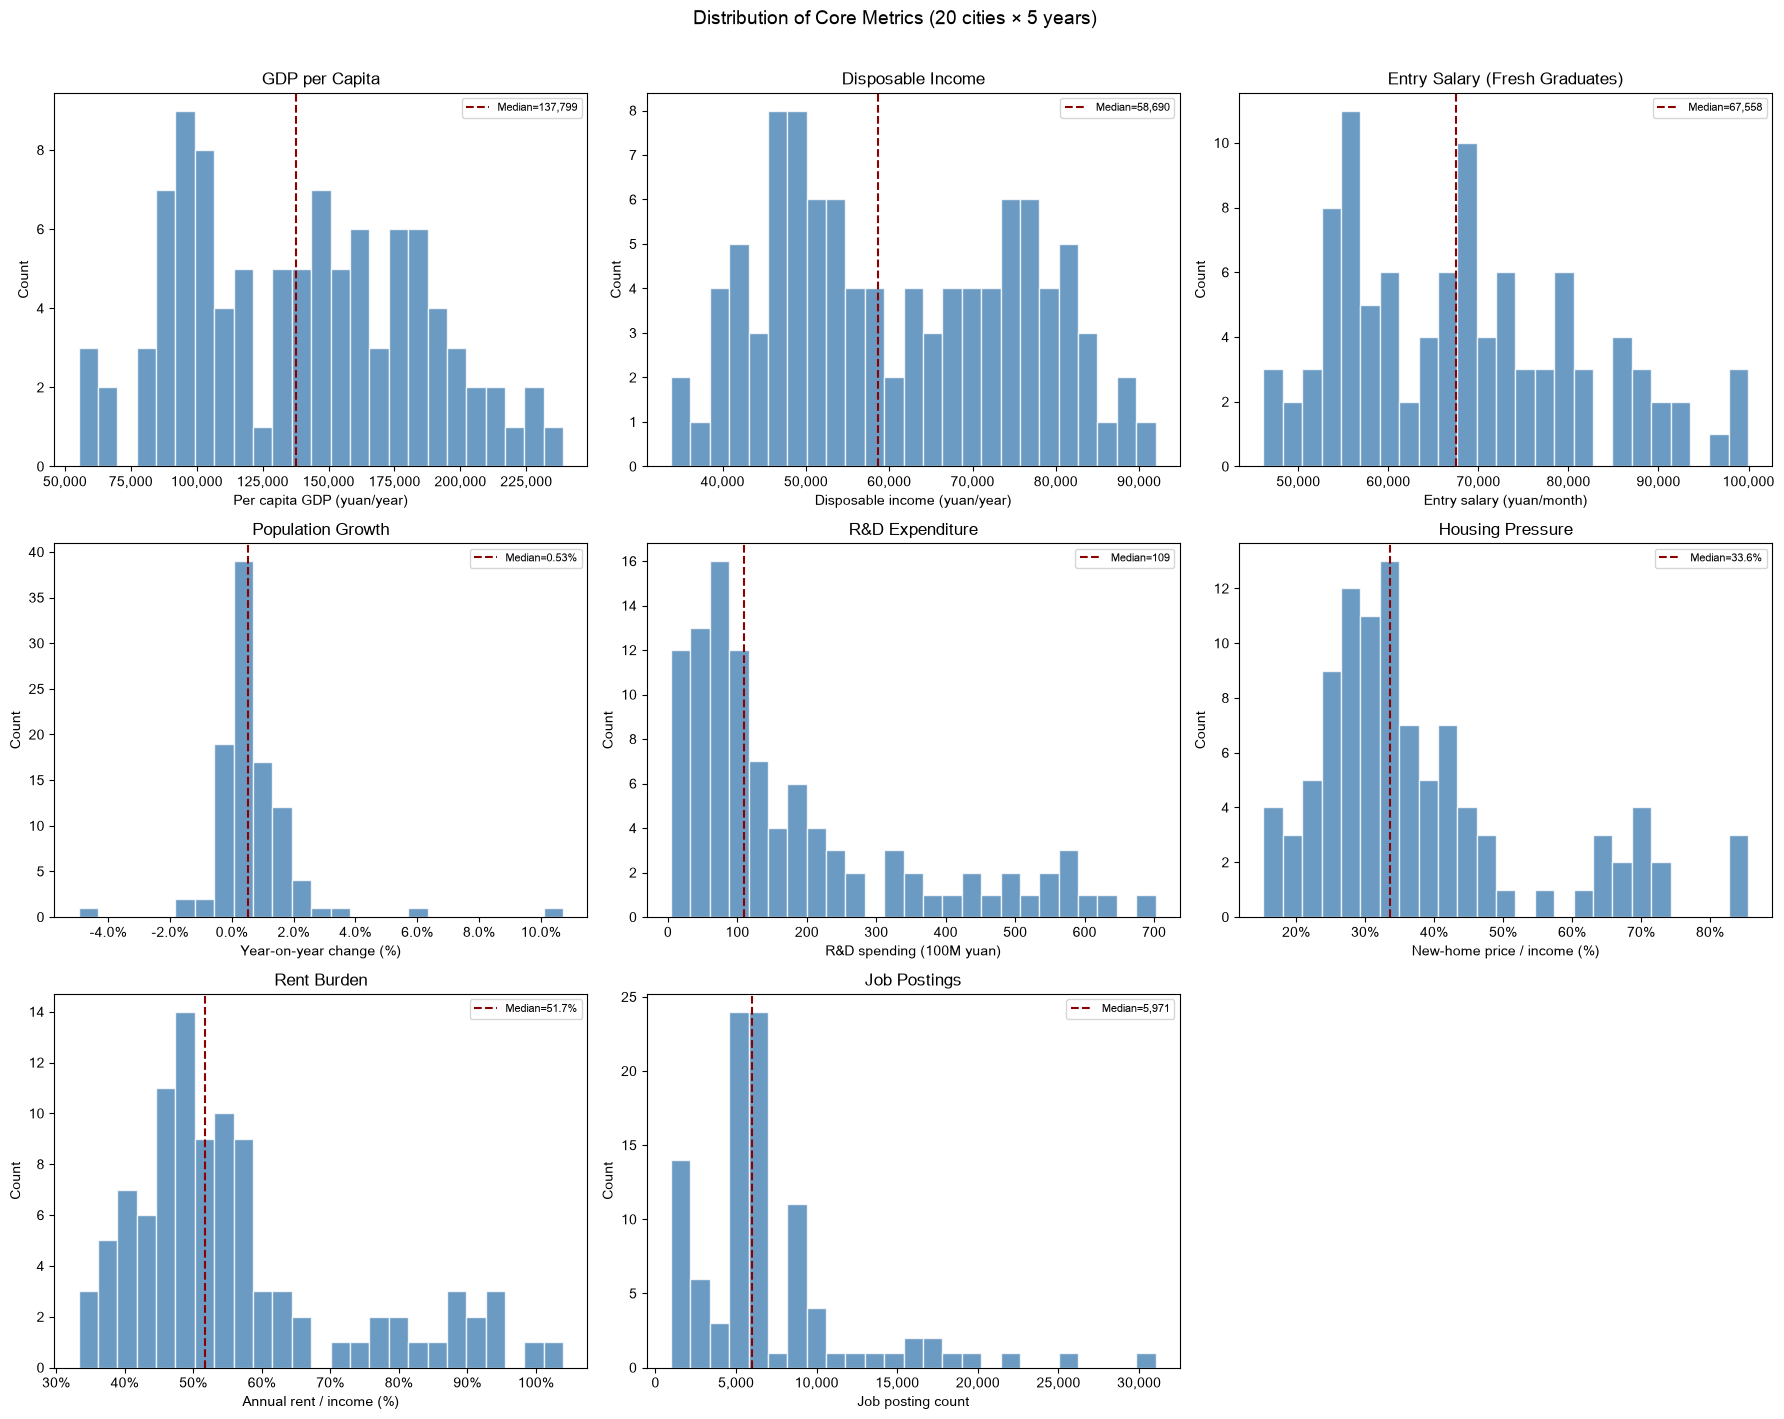

In [5]:
from matplotlib.ticker import FuncFormatter

# Always reload from disk (kernel may keep stale `panel` after data updates)
panel = pd.read_csv(PANEL_PATH)
hb_pct = panel['housing_burden'].dropna() * 100
print(
    f'Housing Pressure plot data: {hb_pct.min():.1f}% – {hb_pct.max():.1f}%, '
    f'median {hb_pct.median():.1f}%'
)
if (panel['house_price'].dropna() < 1000).any():
    raise ValueError('Stale/mixed house_price detected — re-run cell 1 after download_data')

plot_specs = [
    {
        'metric': 'gdp_per_capita',
        'title': 'GDP per Capita',
        'xlabel': 'Per capita GDP (yuan/year)',
        'transform': None,
        'median_label': lambda v: f'Median={v:,.0f}',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:,.0f}'),
    },
    {
        'metric': 'disposable_income',
        'title': 'Disposable Income',
        'xlabel': 'Disposable income (yuan/year)',
        'transform': None,
        'median_label': lambda v: f'Median={v:,.0f}',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:,.0f}'),
    },
    {
        'metric': 'entry_salary',
        'title': 'Entry Salary (Fresh Graduates)',
        'xlabel': 'Entry salary (yuan/month)',
        'transform': None,
        'median_label': lambda v: f'Median={v:,.0f}',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:,.0f}'),
    },
    {
        'metric': 'population_growth',
        'title': 'Population Growth',
        'xlabel': 'Year-on-year change (%)',
        'transform': lambda s: s * 100,
        'median_label': lambda v: f'Median={v:.2f}%',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:.1f}%'),
    },
    {
        'metric': 'innovation_index',
        'title': 'R&D Expenditure',
        'xlabel': 'R&D spending (100M yuan)',
        'transform': None,
        'median_label': lambda v: f'Median={v:.0f}',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:.0f}'),
    },
    {
        'metric': 'housing_burden',
        'title': 'Housing Pressure',
        'xlabel': 'New-home price / income (%)',
        'transform': lambda s: s * 100,
        'median_label': lambda v: f'Median={v:.1f}%',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:.0f}%'),
    },
    {
        'metric': 'rent_burden',
        'title': 'Rent Burden',
        'xlabel': 'Annual rent / income (%)',
        'transform': lambda s: s * 100,
        'median_label': lambda v: f'Median={v:.1f}%',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:.0f}%'),
    },
    {
        'metric': 'job_posting_count',
        'title': 'Job Postings',
        'xlabel': 'Job posting count',
        'transform': None,
        'median_label': lambda v: f'Median={v:,.0f}',
        'x_formatter': FuncFormatter(lambda x, _: f'{x:,.0f}'),
    },
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, spec in enumerate(plot_specs):
    if spec['metric'] not in panel.columns:
        axes[i].axis('off')
        continue
    data = panel[spec['metric']].dropna()
    plot_data = spec['transform'](data) if spec['transform'] else data
    median = plot_data.median()

    ax = axes[i]
    ax.hist(plot_data, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(median, color='darkred', linestyle='--', label=spec['median_label'](median))
    ax.set_title(spec['title'])
    ax.set_xlabel(spec['xlabel'])
    ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(spec['x_formatter'])
    ax.legend(fontsize=8)

axes[8].axis('off')
plt.suptitle('Distribution of Core Metrics (20 cities × 5 years)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Correlation Matrix

How do the YEOI raw metrics correlate with each other?

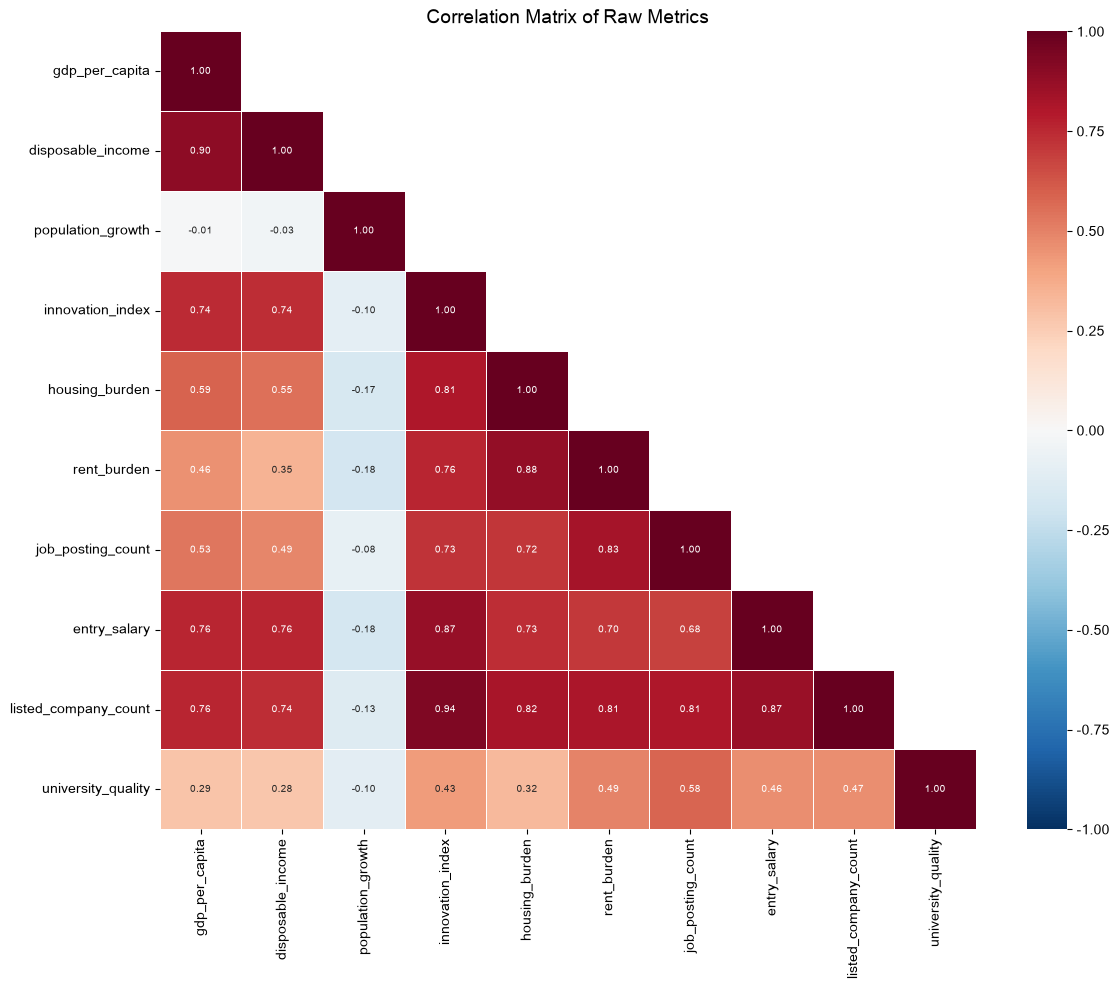

Key correlations:
  GDP p.c. ↔ Disposable Income: 0.90
  GDP p.c. ↔ Innovation: 0.74
  Disposable Income ↔ Housing Burden: 0.55
  Entry Salary ↔ Disposable Income: 0.76
  Job Postings ↔ Listed Companies: 0.81
  Rent Burden ↔ Housing Burden: 0.88


In [6]:
corr_fields = [
    'gdp_per_capita', 'disposable_income', 'population_growth', 'innovation_index',
    'housing_burden', 'rent_burden', 'job_posting_count', 'entry_salary',
    'listed_company_count', 'university_quality',
]
corr_fields = [f for f in corr_fields if f in panel.columns]
corr = panel[corr_fields].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, linewidths=0.5, ax=ax,
            xticklabels=corr_fields, yticklabels=corr_fields, annot_kws={'size': 7})
ax.set_title('Correlation Matrix of Raw Metrics', fontsize=14)
plt.tight_layout()
plt.show()

print('Key correlations:')
print(f'  GDP p.c. ↔ Disposable Income: {corr.loc["gdp_per_capita","disposable_income"]:.2f}')
print(f'  GDP p.c. ↔ Innovation: {corr.loc["gdp_per_capita","innovation_index"]:.2f}')
print(f'  Disposable Income ↔ Housing Burden: {corr.loc["disposable_income","housing_burden"]:.2f}')
print(f'  Entry Salary ↔ Disposable Income: {corr.loc["entry_salary","disposable_income"]:.2f}')
print(f'  Job Postings ↔ Listed Companies: {corr.loc["job_posting_count","listed_company_count"]:.2f}')
print(f'  Rent Burden ↔ Housing Burden: {corr.loc["rent_burden","housing_burden"]:.2f}')

## 3. Time Trends by City Tier

How do metrics evolve over 2021–2025 by city tier?

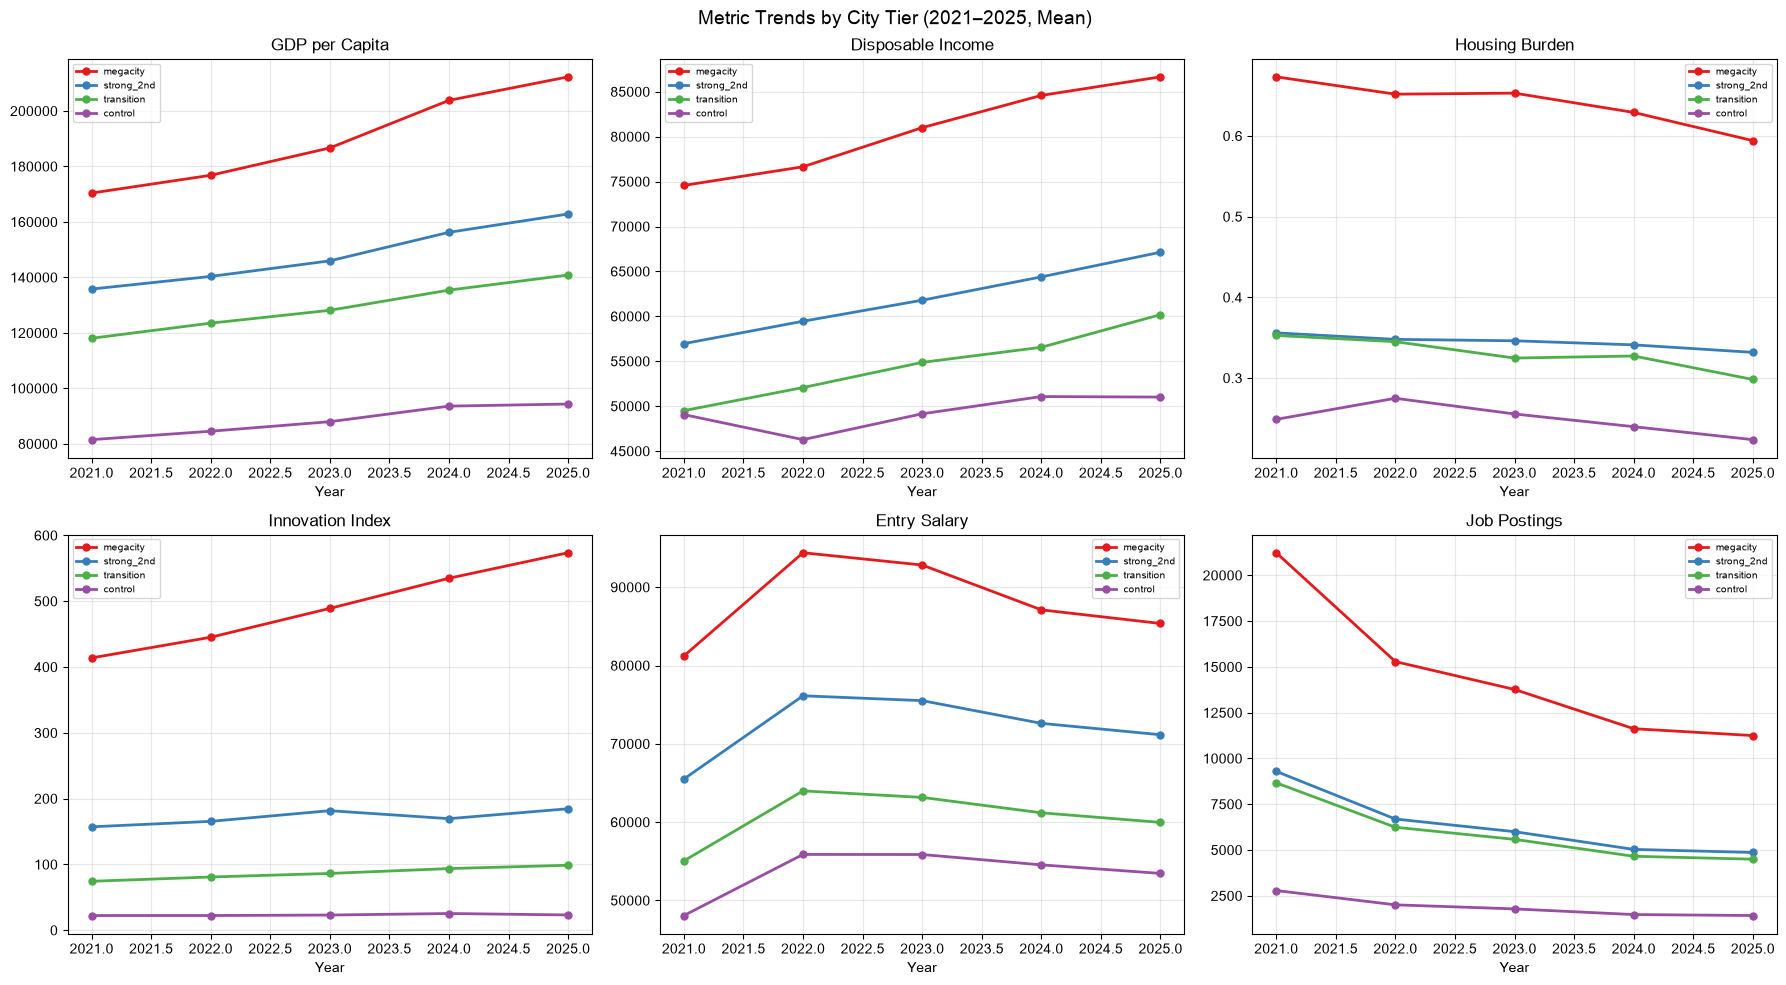

In [7]:
CITY_TIERS = {
    'megacity': ['Beijing', 'Shanghai', 'Shenzhen', 'Guangzhou'],
    'strong_2nd': ['Hangzhou', 'Nanjing', 'Suzhou', 'Chengdu', 'Wuhan', "Xi'an"],
    'transition': ['Hefei', 'Changsha', 'Qingdao', 'Xiamen', 'Zhengzhou', 'Chongqing'],
    'control': ['Harbin', 'Shenyang', 'Kunming', 'Nanchang'],
}
tier_map = {city: t for t, cities in CITY_TIERS.items() for city in cities}
panel_aug = panel.copy()
panel_aug['tier'] = panel_aug['city'].map(tier_map)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_metrics = ['gdp_per_capita', 'disposable_income', 'housing_burden',
                'innovation_index', 'entry_salary', 'job_posting_count']
plot_labels = ['GDP per Capita', 'Disposable Income', 'Housing Burden',
               'Innovation Index', 'Entry Salary', 'Job Postings']
colors = {'megacity': '#e41a1c', 'strong_2nd': '#377eb8', 'transition': '#4daf4a', 'control': '#984ea3'}

for i, (metric, label) in enumerate(zip(plot_metrics, plot_labels)):
    ax = axes[i // 3, i % 3]
    if metric not in panel_aug.columns:
        ax.axis('off')
        continue
    for tier, color in colors.items():
        tier_data = panel_aug[panel_aug['tier'] == tier].groupby('year')[metric].mean()
        ax.plot(tier_data.index, tier_data.values, 'o-', color=color, label=tier, linewidth=2, markersize=5)
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Metric Trends by City Tier (2021–2025, Mean)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Income vs Housing / Rent Burden

The central trade-off of this index: high-income cities tend to have higher housing and rent costs.

Correlation (housing_burden ↔ income): r = 0.690
Correlation (rent_burden ↔ entry_salary): r = 0.761


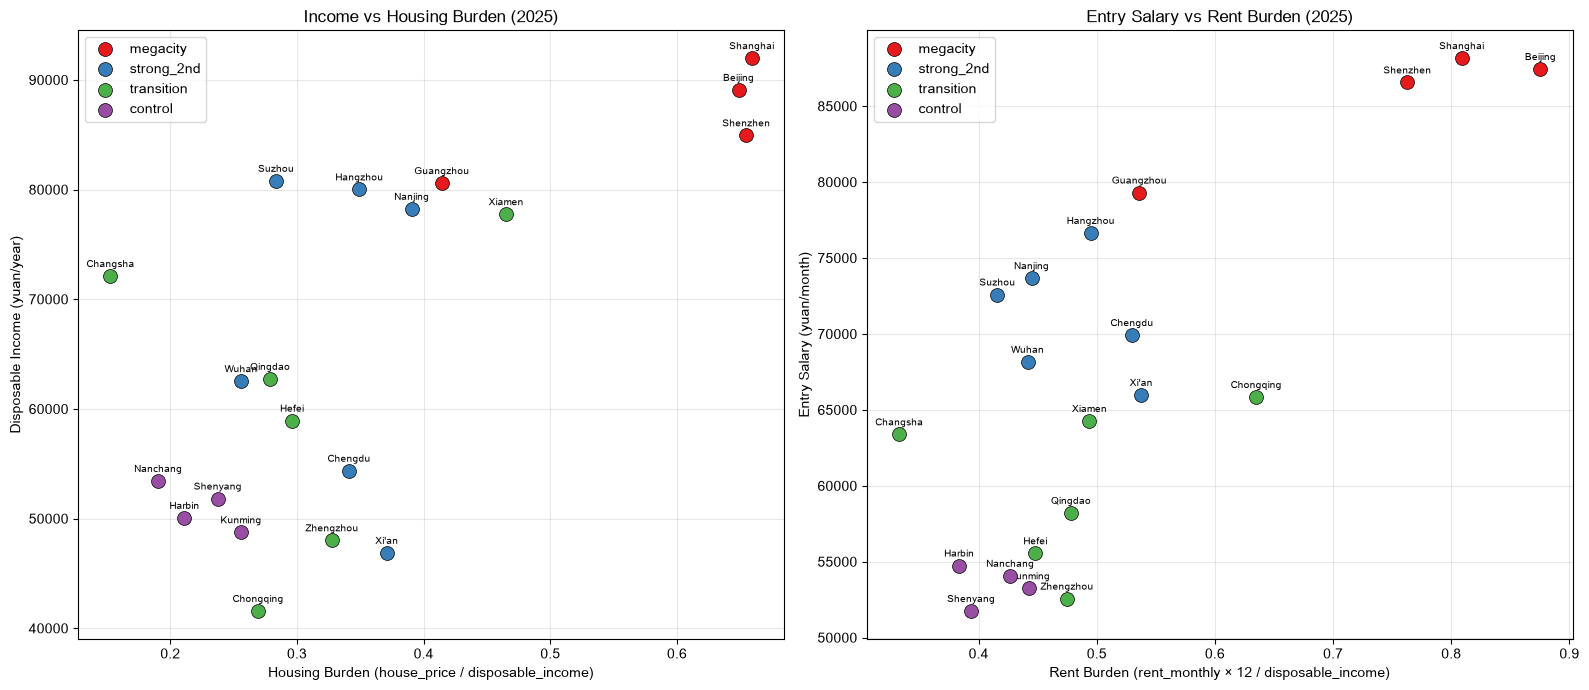

In [8]:
latest = panel[panel['year'] == panel['year'].max()]
latest_aug = latest.copy()
latest_aug['tier'] = latest_aug['city'].map(tier_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Disposable Income vs Housing Burden
ax = axes[0]
for tier, color in colors.items():
    subset = latest_aug[latest_aug['tier'] == tier]
    ax.scatter(subset['housing_burden'], subset['disposable_income'],
              c=color, label=tier, s=100, edgecolors='black', linewidth=0.5, zorder=5)
    for _, row in subset.iterrows():
        ax.annotate(row['city'], (row['housing_burden'], row['disposable_income']),
                   fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('Housing Burden (house_price / disposable_income)')
ax.set_ylabel('Disposable Income (yuan/year)')
ax.set_title(f'Income vs Housing Burden ({latest["year"].iloc[0]:.0f})')
ax.legend()
ax.grid(True, alpha=0.3)
r1 = latest['housing_burden'].corr(latest['disposable_income'])
print(f'Correlation (housing_burden ↔ income): r = {r1:.3f}')

# Plot 2: Entry Salary vs Rent Burden
ax = axes[1]
if 'rent_burden' in latest_aug.columns and 'entry_salary' in latest_aug.columns:
    for tier, color in colors.items():
        subset = latest_aug[latest_aug['tier'] == tier]
        ax.scatter(subset['rent_burden'], subset['entry_salary'],
                  c=color, label=tier, s=100, edgecolors='black', linewidth=0.5, zorder=5)
        for _, row in subset.iterrows():
            ax.annotate(row['city'], (row['rent_burden'], row['entry_salary']),
                       fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

    ax.set_xlabel('Rent Burden (rent_monthly × 12 / disposable_income)')
    ax.set_ylabel('Entry Salary (yuan/month)')
    ax.set_title(f'Entry Salary vs Rent Burden ({latest["year"].iloc[0]:.0f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    r2 = latest['rent_burden'].corr(latest['entry_salary'])
    print(f'Correlation (rent_burden ↔ entry_salary): r = {r2:.3f}')
else:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. GDP vs Innovation

Does higher GDP per capita correlate with higher innovation spending?

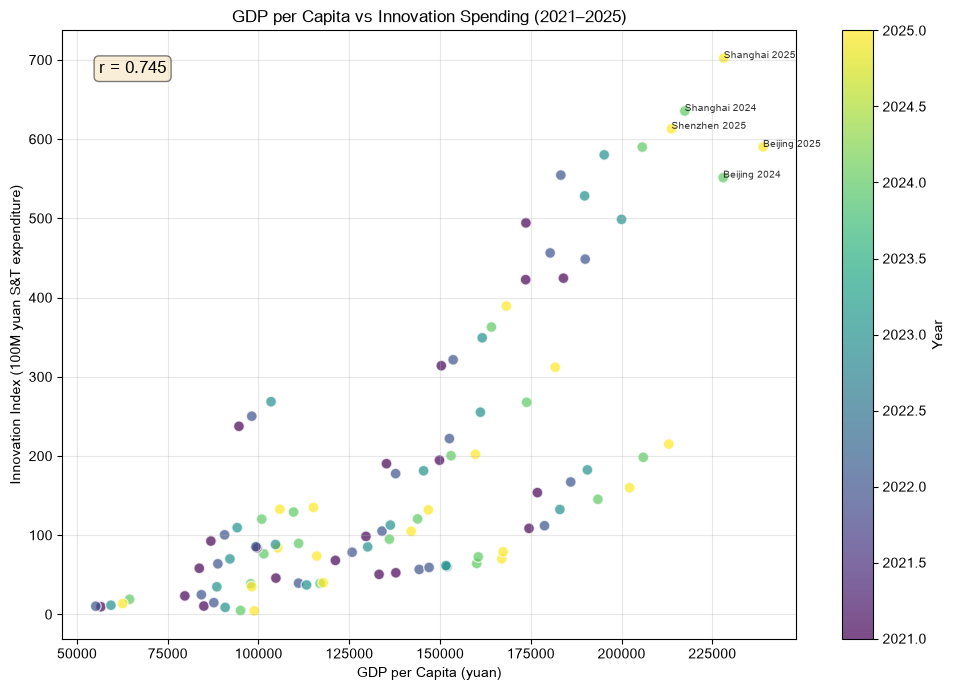

In [9]:
all_years = panel.dropna(subset=['gdp_per_capita', 'innovation_index'])

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(all_years['gdp_per_capita'], all_years['innovation_index'],
                     c=all_years['year'], cmap='viridis', s=60, alpha=0.7, edgecolors='white')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Year')

# Label top-5 and bottom-5
top5_idx = all_years.nlargest(5, 'gdp_per_capita').index
for idx in top5_idx:
    row = all_years.loc[idx]
    ax.annotate(f"{row['city']} {int(row['year'])}", 
               (row['gdp_per_capita'], row['innovation_index']),
               fontsize=7, alpha=0.8)

ax.set_xlabel('GDP per Capita (yuan)')
ax.set_ylabel('Innovation Index (100M yuan S&T expenditure)')
ax.set_title('GDP per Capita vs Innovation Spending (2021–2025)')
ax.grid(True, alpha=0.3)

r2 = all_years['gdp_per_capita'].corr(all_years['innovation_index'])
ax.text(0.05, 0.95, f'r = {r2:.3f}', transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

## 6. Population Growth by City

Which cities are growing fastest?

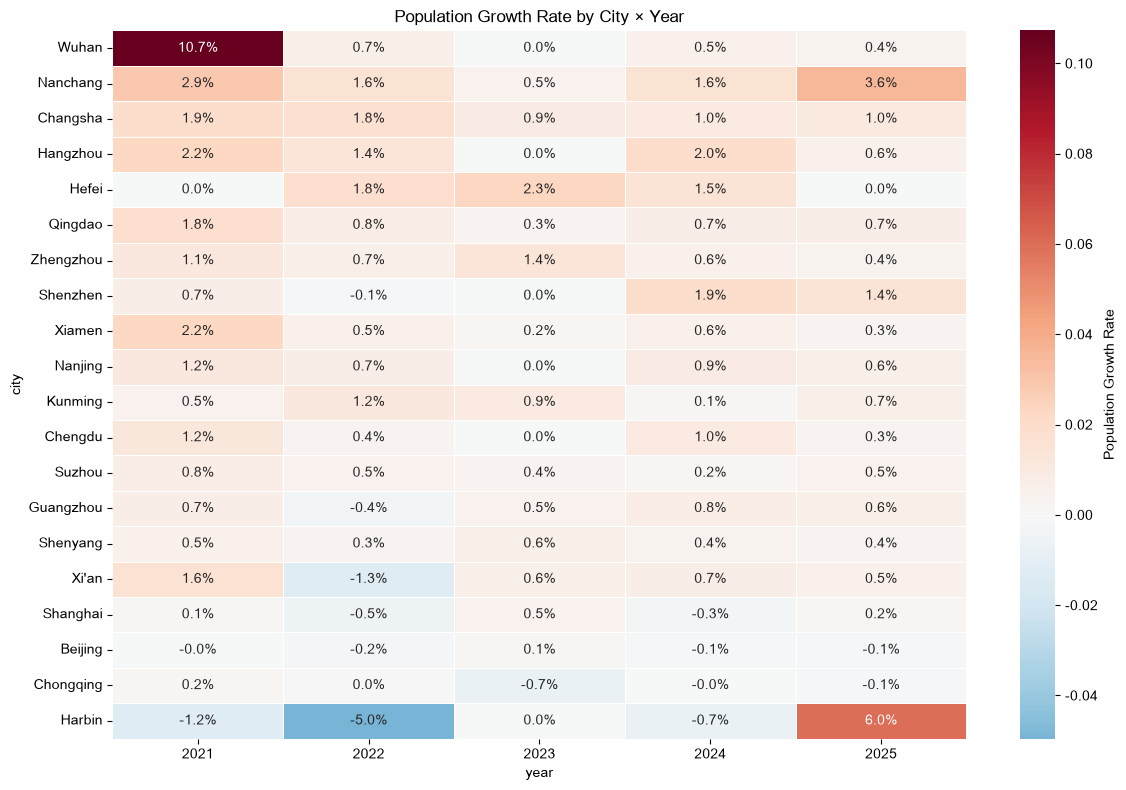

In [10]:
pop_growth = panel.pivot_table(index='city', columns='year', values='population_growth')
pop_growth['mean_5y'] = pop_growth.mean(axis=1)
pop_growth = pop_growth.sort_values('mean_5y', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pop_growth.drop(columns='mean_5y'), annot=True, fmt='.1%', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Population Growth Rate'})
ax.set_title('Population Growth Rate by City × Year')
plt.tight_layout()
plt.show()

## 7. YEOI Score Distribution

Final index distribution across all city-years.

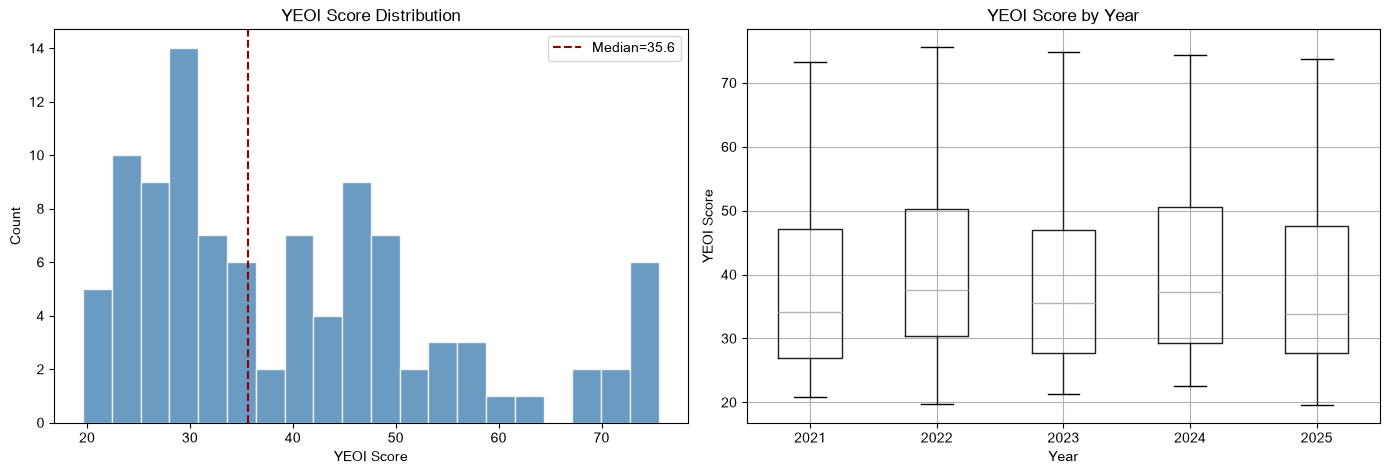

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
valid_scores = scores['yeoi_score'].dropna()
axes[0].hist(valid_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(valid_scores.median(), color='darkred', linestyle='--', label=f'Median={valid_scores.median():.1f}')
axes[0].set_xlabel('YEOI Score')
axes[0].set_ylabel('Count')
axes[0].set_title('YEOI Score Distribution')
axes[0].legend()

# Box plot by year
scores.boxplot(column='yeoi_score', by='year', ax=axes[1])
axes[1].set_title('YEOI Score by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('YEOI Score')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 8. Data Quality Check

Systematic audit of suspicious observations across 20 cities × core metrics.
Report generated by `scripts/validate_observations.py --report-csv --matrix`.

Quality report: 372 rows from data_quality_report.csv


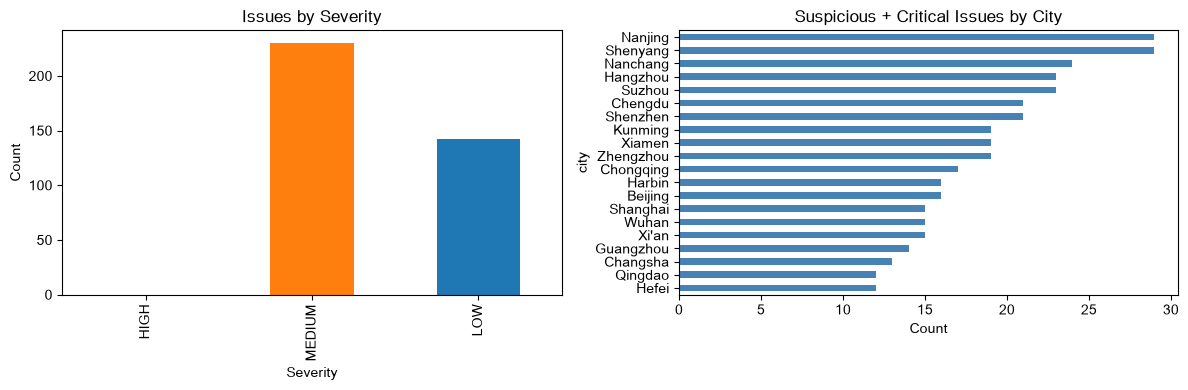


Top CRITICAL issues:
Empty DataFrame
Columns: [city, year, metric, rule_type, detail]
Index: []


In [12]:
QUALITY_PATH = ROOT / 'data' / 'raw' / 'data_quality_report.csv'
quality = pd.read_csv(QUALITY_PATH)
print(f'Quality report: {quality.shape[0]} rows from {QUALITY_PATH.name}')

# Summary by severity and city
severity_counts = quality['severity'].value_counts().reindex(['HIGH', 'MEDIUM', 'LOW'])
status_counts = quality['status'].value_counts().reindex(['CRITICAL', 'SUSPICIOUS', 'MISSING', 'INFO'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
severity_counts.plot(kind='bar', ax=axes[0], color=['#d62728', '#ff7f0e', '#1f77b4'])
axes[0].set_title('Issues by Severity')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')

city_counts = (
    quality[quality['status'].isin(['CRITICAL', 'SUSPICIOUS'])]
    .groupby('city')
    .size()
    .sort_values(ascending=True)
)
city_counts.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Suspicious + Critical Issues by City')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.show()

print('\nTop CRITICAL issues:')
critical = quality[quality['status'] == 'CRITICAL'].drop_duplicates(['city', 'year', 'metric'])
print(critical[['city', 'year', 'metric', 'rule_type', 'detail']].head(12).to_string(index=False))

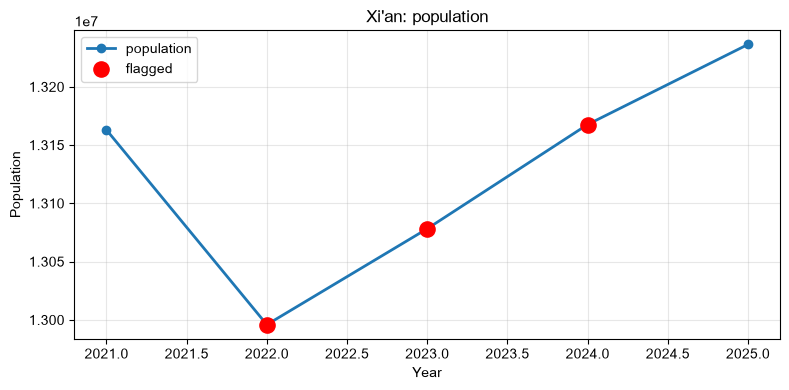

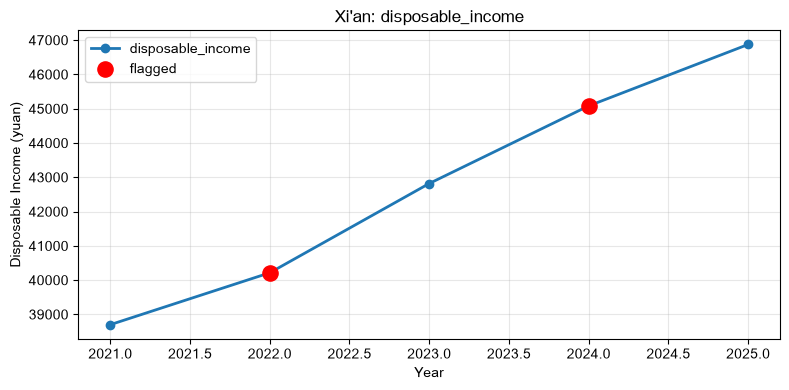

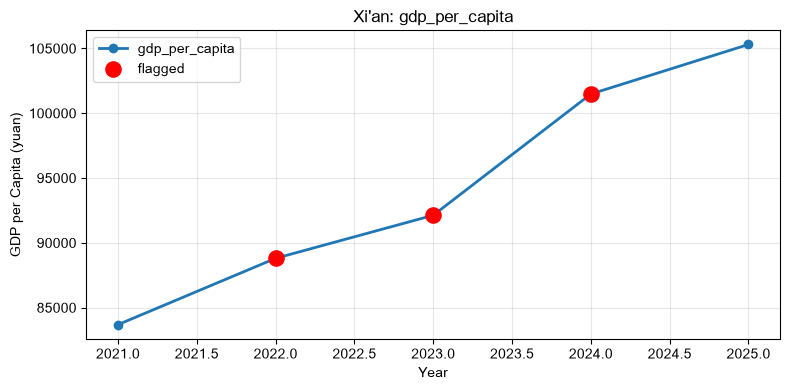

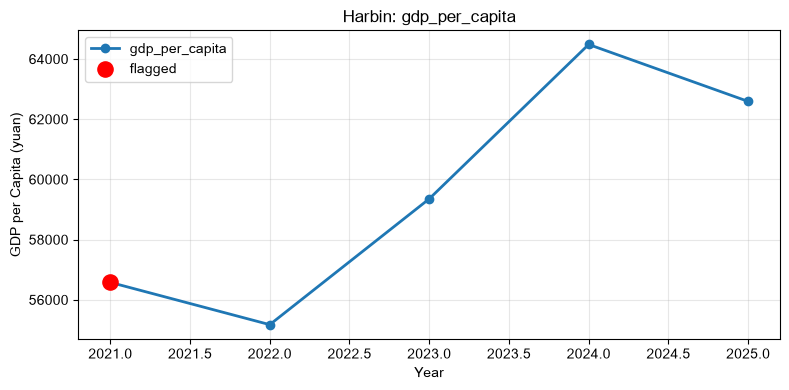

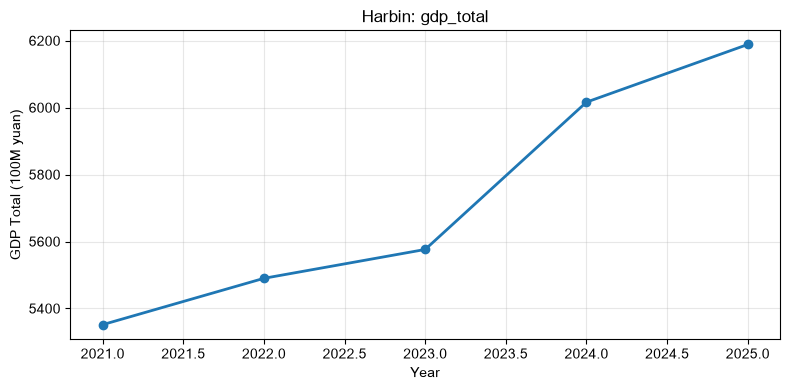

In [13]:
def plot_metric_with_flags(city: str, metric: str, ylabel: str) -> None:
    series = panel[panel['city'] == city].sort_values('year')
    flagged_years = set(
        quality.loc[
            (quality['city'] == city)
            & (quality['metric'] == metric)
            & (quality['status'].isin(['CRITICAL', 'SUSPICIOUS'])),
            'year',
        ]
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(series['year'], series[metric], marker='o', linewidth=2, label=metric)
    for year in flagged_years:
        val = series.loc[series['year'] == year, metric]
        if not val.empty and pd.notna(val.iloc[0]):
            ax.scatter([year], [val.iloc[0]], s=120, color='red', zorder=5, label='flagged' if year == min(flagged_years) else None)
    ax.set_title(f'{city}: {metric}')
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if flagged_years:
        ax.legend()
    plt.tight_layout()
    plt.show()

for city, metric, ylabel in [
    ("Xi'an", 'population', 'Population'),
    ("Xi'an", 'disposable_income', 'Disposable Income (yuan)'),
    ("Xi'an", 'gdp_per_capita', 'GDP per Capita (yuan)'),
    ('Harbin', 'gdp_per_capita', 'GDP per Capita (yuan)'),
    ('Harbin', 'gdp_total', 'GDP Total (100M yuan)'),
]:
    if metric in panel.columns:
        plot_metric_with_flags(city, metric, ylabel)